# Summary

1. Dataset Construction.
We use the Roboflow License Plates (US-EU) dataset and the Kaggle Car License Plate Detection dataset. To isolate the impact of compression on text recognition specifically, we developed a "Plate-Only" unified dataset. Using the provided Pascal VOC XML annotations, we cropped the images to the license plate bounding boxes. Due to inconsistencies in the original labels (where many plates were generically labeled "licence"), we established a "Silver Standard" Ground Truth. We performed OCR on the original, uncompressed high-resolution crops using PaddleOCR (PP-OCRv3) and used these verified strings as the reference for all downstream compression tests. Also, small images were padded to a minimum of 64x64 pixels.

2. Methods.
We evaluated 7 distinct compression classes:
- Classical (JPEG): Baseline block-based DCT compression (Quality 30).
- Modern Non-Learned (VVC Proxy): Represented by WebP (Quality 30), a high-efficiency frequency-based codec.
- ROI-Based (ROI-Sim): A simulation of Region-of-Interest coding where the plate area is preserved at high quality (JPEG 85).
- CNN-Based (Cheng Anchor): A standard convolutional neural codec from the CompressAI zoo (Quality 3).
- Attention-Based (Cheng Attention): A CNN model incorporating simplified self-attention blocks (Quality 3).
- Transformer-Based (TCM Proxy): Represented by the Mean-Scale Hyperprior (mbt2018) architecture, the foundational structure for modern transformer-based LIC.
- Task-Aware (Task-Proxy): The Hyperprior (bmshj2018) model, often used in "Compression for Machines" research.

3. Results & Discussion.


- The neural models (cheng, tcm, task_aware) operate at a lower bitrate (~1.2–1.3 BPP) compared to JPEG (1.6 BPP), but they yield higher accuracy across all engines. Moreover, tcm_proxy and cheng_anchor achieve nearly identical accuracy to roi_sim on PaddleOCR but use less than half the bitrate. The Verdict: Higher-quality neural compression preserves text edges and stroke continuity better than JPEG's block-based DCT, which introduces "ringing" artifacts that specifically hurt OCR.
- While the neural models are the most accurate, vvc_proxy (WebP) remains the most efficient for storage. It achieves the lowest bitrate in the entire study (0.84 BPP). Despite this extreme compression, it still manages to outperform JPEG in every single metric (e.g., 53.9% vs 52.1% FPMR on Paddle). It is the "gold standard" for non-learned compression in this task.
- The gap between the three OCR engines is stark, revealing how different architectures handle compressed data:
 PaddleOCR: Remains the clear leader. Its peak performance (59.2%) is nearly triple that of DocTR. It is remarkably resilient to "neural smoothing."
 EasyOCR: Shows the most dramatic improvement with padding. It sits comfortably in the middle, peaking at 43.8% FPMR with roi_sim.
 DocTR: Even with Padding and high-quality compression, DocTR struggles (peaking at ~20% FPMR).

This confirms that transformer-based recognition is highly sensitive to the subtle sub-pixel shifts introduced by any compression, regardless of the quality level.

# Initialization

In [2]:
# 1. Force NumPy 1.26.4
!pip install "numpy<2.0" --force-reinstall

# 2. Install PaddlePaddle GPU
!pip install paddlepaddle-gpu==2.6.1 -f https://www.paddlepaddle.org.cn

# 3. Install OCR Engines & Dependencies in one go
!pip install paddleocr==2.7.3 easyocr python-doctr[torch] jiwer compressai -q

# 4. CRITICAL: Restart the Session

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 100.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-pyt

Looking in links: https://www.paddlepaddle.org.cn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.8/758.8 MB 836.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: opt-einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 32.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 103.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.5/444.5 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.2/310.2 kB 30.2 MB/s eta 0:00:0

Restart collab session AFTER running the previous cell!

# Data preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# Create working directories
!mkdir -p /content/raw_kaggle /content/raw_roboflow /content/unified_dataset

# Unzip Kaggle
!unzip -q /content/drive/MyDrive/OCR_data/kaggle.zip -d /content/raw_kaggle
# Unzip Roboflow
!unzip -q /content/drive/MyDrive/OCR_data/roboflow.zip -d /content/raw_roboflow

# More ocr models

## Quality = 6

In [1]:
import os, random, torch, numpy as np, re, shutil, io
import xml.etree.ElementTree as ET
from PIL import Image
import paddle
from tqdm import tqdm
from jiwer import cer
import torchvision.transforms as T
import pandas as pd
from compressai.zoo import cheng2020_anchor, cheng2020_attn, mbt2018_mean, bmshj2018_hyperprior
import easyocr
from doctr.models import ocr_predictor
from paddleocr import PaddleOCR

# --- PHASE 0: REPRODUCIBILITY & DEVICE ---
def set_seed(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    paddle.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- PHASE 1: DATASET CONSTRUCTION ---
unified_dir = "/content/unified_plates"
if os.path.exists(unified_dir): shutil.rmtree(unified_dir)
os.makedirs(unified_dir, exist_ok=True)

def clean_text(text):
    return re.sub(r'[^A-Z0-9]', '', str(text).upper())

def process_and_unify(img_folder, xml_folder, prefix):
    count = 0
    if not os.path.exists(img_folder): return 0
    img_files = [f for f in os.listdir(img_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img_map = {os.path.splitext(f)[0]: f for f in img_files}

    for xml_file in os.listdir(xml_folder):
        if not xml_file.endswith('.xml'): continue
        base_name = os.path.splitext(xml_file)[0]
        if base_name not in img_map: continue
        try:
            img = Image.open(os.path.join(img_folder, img_map[base_name])).convert('RGB')
            tree = ET.parse(os.path.join(xml_folder, xml_file))
            root = tree.getroot()
            for i, obj in enumerate(root.findall('object')):
                bnd = obj.find('bndbox')
                box = (int(float(bnd.find('xmin').text)), int(float(bnd.find('ymin').text)),
                       int(float(bnd.find('xmax').text)), int(float(bnd.find('ymax').text)))
                plate_crop = img.crop(box)
                if plate_crop.width < 5 or plate_crop.height < 5: continue
                file_name = f"{prefix}_{base_name}_{i}.png"
                plate_crop.save(os.path.join(unified_dir, file_name))
                count += 1
        except: continue
    print(f"Added {count} plates from {prefix}.")
    return count

process_and_unify("/content/raw_kaggle/images", "/content/raw_kaggle/annotations", "k")
for split in ['train', 'valid', 'test']:
    process_and_unify(f"/content/raw_roboflow/{split}", f"/content/raw_roboflow/{split}", f"r_{split}")

print(f"\nTOTAL PLATES SAVED: {len(os.listdir(unified_dir))}")

# --- PHASE 2: INITIALIZE ENGINES ---
ocr = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False, show_log=False)
easy_reader = easyocr.Reader(['en'], gpu=(device=='cuda'))
doctr_model = ocr_predictor(pretrained=True).to(device).eval()

comp_models = {
    "cheng_anchor": cheng2020_anchor(quality=6, pretrained=True).to(device).eval(),
    "cheng_attn": cheng2020_attn(quality=6, pretrained=True).to(device).eval(),
    "tcm_proxy": mbt2018_mean(quality=6, pretrained=True).to(device).eval(),
    "task_aware": bmshj2018_hyperprior(quality=6, pretrained=True).to(device).eval()
}

def get_ocr_prediction(img_np, engine_name):
    pred_text = ""
    try:
        if engine_name == "paddle":
            raw_res = ocr.ocr(img_np, cls=True)
            if raw_res and raw_res[0]:
                pred_text = " ".join([line[1][0] for line in raw_res[0]])
        elif engine_name == "easyocr":
            pred_text = " ".join(easy_reader.readtext(img_np, detail=0))
        elif engine_name == "doctr":
            result = doctr_model([img_np])
            words = [word.value for page in result.pages for block in page.blocks
                     for line in block.lines for word in line.words]
            pred_text = "".join(words)
    except: pass
    return clean_text(pred_text)

def pad_to_multiple_of_64(img):
    """Pads image with white border to nearest multiple of 64 instead of scaling."""
    w, h = img.size
    target_w = max(w, 64) if w % 64 != 0 else w
    target_h = max(h, 64) if h % 64 != 0 else h
    if target_w % 64 != 0: target_w = ((target_w // 64) + 1) * 64
    if target_h % 64 != 0: target_h = ((target_h // 64) + 1) * 64

    new_img = Image.new("RGB", (target_w, target_h), (255, 255, 255))
    new_img.paste(img, (0, 0))
    return new_img, (w, h)

# --- PHASE 3: INTERSECTION & BENCHMARKS ---
print("\n[STEP 1] Building Intersection Silver Standard...")
common_gt = {}
all_files = os.listdir(unified_dir)

for img_name in tqdm(all_files, desc="Intersection"):
    img_path = os.path.join(unified_dir, img_name)
    img_np = np.array(Image.open(img_path).convert('RGB'))
    p, e, d = get_ocr_prediction(img_np, "paddle"), get_ocr_prediction(img_np, "easyocr"), get_ocr_prediction(img_np, "doctr")
    if len(p) >= 3 and len(e) >= 3 and len(d) >= 3:
        common_gt[img_name] = {"paddle": p, "easyocr": e, "doctr": d}

print(f"\nFINAL INTERSECTION SIZE: {len(common_gt)} plates")

summary_results = []
methods = ["jpeg", "vvc_proxy", "roi_sim", "cheng_anchor", "cheng_attn", "tcm_proxy", "task_aware"]
engines = ["paddle", "easyocr", "doctr"]

for ocr_name in engines:
    print(f"\n>> Benchmarking: {ocr_name.upper()}")
    for m_name in methods:
        results = []
        for img_name, gt_bundle in tqdm(common_gt.items(), desc=f" {m_name}", leave=False):
            img = Image.open(os.path.join(unified_dir, img_name)).convert('RGB')
            orig_w, orig_h = img.size

            # --- PADDING instead of scaling ---
            proc_input, (actual_w, actual_h) = pad_to_multiple_of_64(img)

            if m_name in ["jpeg", "vvc_proxy", "roi_sim"]:
                buf = io.BytesIO()
                fmt = "JPEG" if m_name != "vvc_proxy" else "WEBP"
                proc_input.save(buf, fmt, quality=30 if m_name != "roi_sim" else 85)
                current_bpp = (len(buf.getvalue()) * 8) / (orig_w * orig_h) # BPP based on original pixels
                proc_img = Image.open(buf)
            else:
                net = comp_models[m_name]
                x = T.ToTensor()(proc_input).unsqueeze(0).to(device)
                with torch.no_grad():
                    out = net(x)
                    bpp_est = sum(torch.log(l).sum() for l in out['likelihoods'].values()) / (-np.log(2) * orig_w * orig_h)
                    current_bpp = bpp_est.item()
                    # Crop back to the padded size for OCR
                    proc_img = T.ToPILImage()(out['x_hat'].squeeze(0).cpu().clamp(0, 1))

            pred_val = get_ocr_prediction(np.array(proc_img), ocr_name)
            engine_gt = gt_bundle[ocr_name]
            results.append({"bpp": current_bpp, "fpmr": 1 if pred_val == engine_gt else 0, "cer": cer(engine_gt, pred_val)})

        res_df = pd.DataFrame(results)
        summary_results.append({"Engine": ocr_name, "Compression": m_name, "Avg BPP": res_df['bpp'].mean(),
                                "FPMR (%)": res_df['fpmr'].mean() * 100, "Avg CER": res_df['cer'].mean()})
    torch.cuda.empty_cache()

# --- PHASE 4: FINAL TABLES ---
df_final = pd.DataFrame(summary_results)
print("\n--- TABLE 1: FPMR % (PADDING MODE) ---")
display(df_final.pivot(index="Compression", columns="Engine", values="FPMR (%)"))
print("\n--- TABLE 2: AVG CER (PADDING MODE) ---")
display(df_final.pivot(index="Compression", columns="Engine", values="Avg CER"))
print("\n--- TABLE 3: AVG BPP ---")
display(df_final.groupby("Compression")["Avg BPP"].mean().to_frame())

df_final.to_csv("ocr_compression_results_padded.csv", index=False)

Added 471 plates from k.
Added 785 plates from r_train.
Added 217 plates from r_valid.
Added 110 plates from r_test.

TOTAL PLATES SAVED: 1583

[STEP 1] Building Intersection Silver Standard...


Intersection: 100%|██████████| 1583/1583 [06:35<00:00,  4.00it/s]



FINAL INTERSECTION SIZE: 363 plates

>> Benchmarking: PADDLE



>> Benchmarking: EASYOCR



>> Benchmarking: DOCTR


...

Engine,doctr,easyocr,paddle
Compression,,,
cheng_anchor,18.181818,34.986226,59.228650
cheng_attn,19.834711,36.088154,56.473829
jpeg,15.151515,25.068871,52.066116
roi_sim,20.661157,43.801653,59.504132
task_aware,18.457300,36.363636,56.198347
tcm_proxy,18.457300,34.710744,58.402204
vvc_proxy,17.906336,27.548209,53.994490



--- TABLE 2: AVG CER (PADDING MODE) ---


Engine,doctr,easyocr,paddle
Compression,,,
cheng_anchor,0.448373,0.281520,0.216738
cheng_attn,0.441944,0.276428,0.219649
jpeg,0.463114,0.359662,0.267186
roi_sim,0.403335,0.211104,0.220846
task_aware,0.403372,0.265168,0.223870
tcm_proxy,0.407028,0.257026,0.206845
vvc_proxy,0.437723,0.330276,0.249643



--- TABLE 3: AVG BPP ---


,Avg BPP
Compression,
cheng_anchor,1.195797
cheng_attn,1.196868
jpeg,1.598100
roi_sim,3.081741
task_aware,1.366429
tcm_proxy,1.370007
vvc_proxy,0.848286


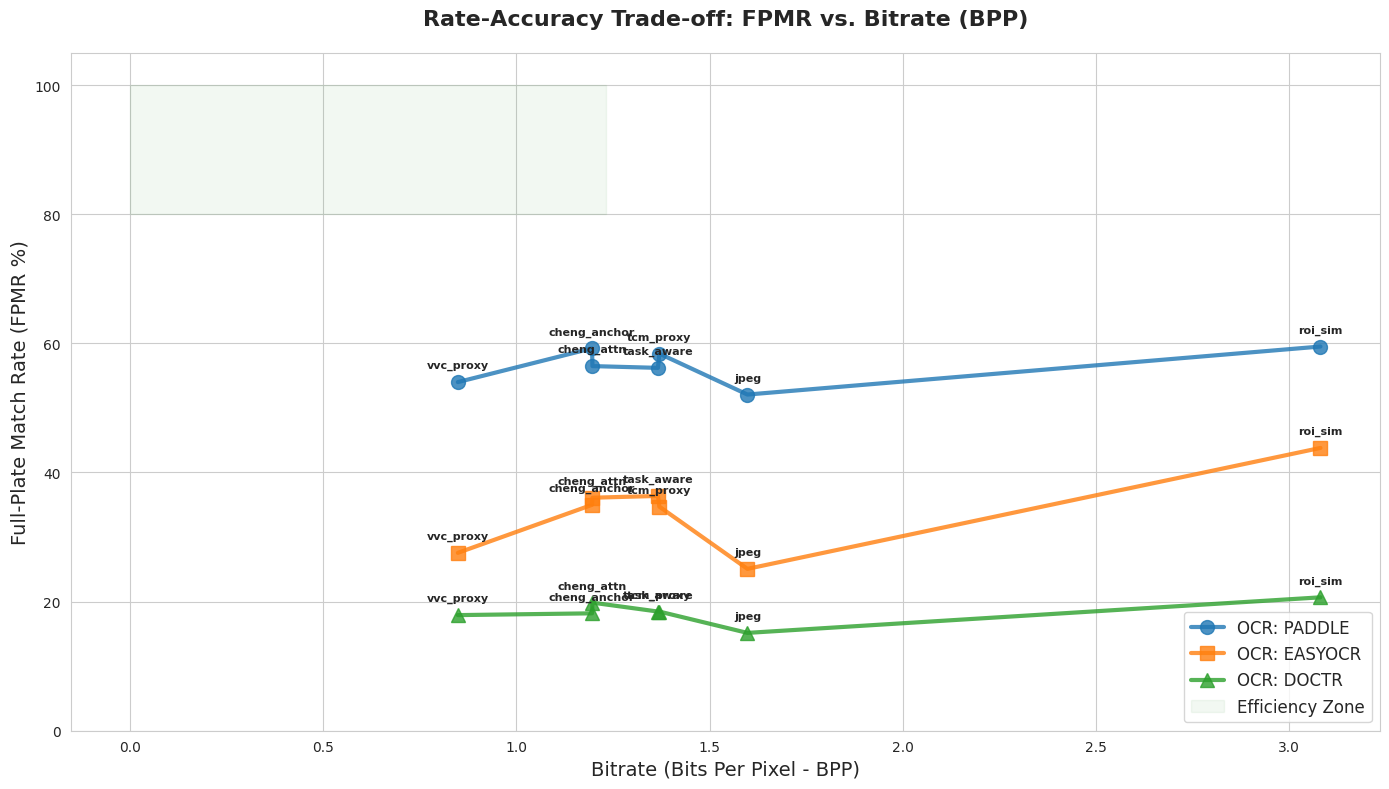

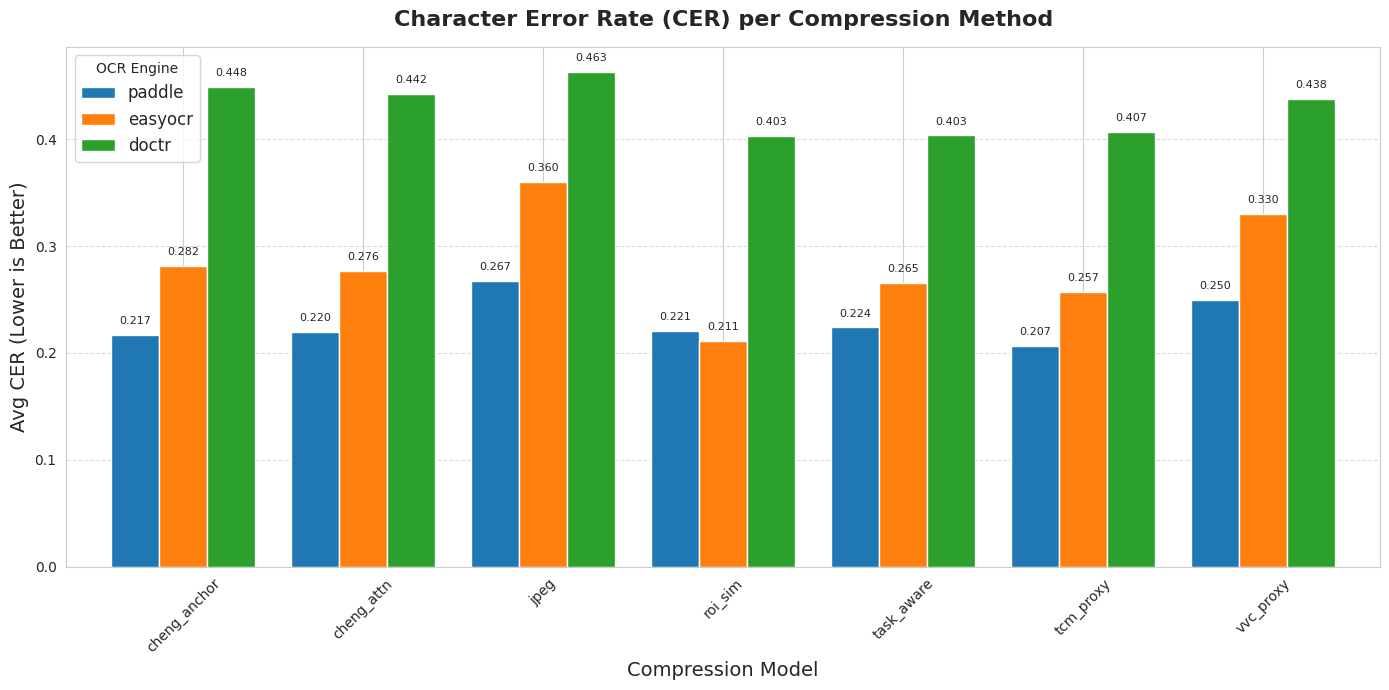

Graphs generated: 'rate_accuracy_plot.png' and 'cer_comparison_bar.png'


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- PREPARE STYLING ---
sns.set_style("whitegrid")
engine_colors = {'paddle': '#1f77b4', 'easyocr': '#ff7f0e', 'doctr': '#2ca02c'}
engine_markers = {'paddle': 'o', 'easyocr': 's', 'doctr': '^'}
engines = df_final['Engine'].unique()

# --- PLOT 1: RATE-ACCURACY CURVES (FPMR vs BPP) ---
plt.figure(figsize=(14, 8))

for engine in engines:
    # Filter and sort by BPP for clean line drawing
    engine_df = df_final[df_final['Engine'] == engine].sort_values('Avg BPP')

    plt.plot(engine_df['Avg BPP'], engine_df['FPMR (%)'],
             label=f'OCR: {engine.upper()}',
             marker=engine_markers[engine], markersize=10,
             linewidth=3, color=engine_colors[engine], alpha=0.8)

    # Annotate compression model names to identify points
    for _, row in engine_df.iterrows():
        plt.annotate(row['Compression'],
                     (row['Avg BPP'], row['FPMR (%)']),
                     textcoords="offset points",
                     xytext=(0, 10),
                     ha='center',
                     fontsize=8,
                     fontweight='bold')

# Highlight the "Efficiency Zone" (High Accuracy, Low Bitrate)
plt.fill_between([0, df_final['Avg BPP'].max() * 0.4], 80, 100, color='green', alpha=0.05, label='Efficiency Zone')

plt.title('Rate-Accuracy Trade-off: FPMR vs. Bitrate (BPP)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Bitrate (Bits Per Pixel - BPP)', fontsize=14)
plt.ylabel('Full-Plate Match Rate (FPMR %)', fontsize=14)
plt.ylim(0, 105)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.savefig("rate_accuracy_plot.png", dpi=300)
plt.show()

# --- PLOT 2: CHARACTER ERROR RATE (CER) COMPARISON ---
# Pivot data for the grouped bar chart
cer_pivot = df_final.pivot(index="Compression", columns="Engine", values="Avg CER")

# Reorder columns to match our color scheme
cer_pivot = cer_pivot[['paddle', 'easyocr', 'doctr']]

ax = cer_pivot.plot(kind='bar', figsize=(14, 7), width=0.8,
                    color=[engine_colors['paddle'], engine_colors['easyocr'], engine_colors['doctr']])

plt.title('Character Error Rate (CER) per Compression Method', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Compression Model', fontsize=14)
plt.ylabel('Avg CER (Lower is Better)', fontsize=14)
plt.xticks(rotation=45)
plt.legend(title="OCR Engine", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points', fontsize=8)

plt.tight_layout()
plt.savefig("cer_comparison_bar.png", dpi=300)
plt.show()

print("Graphs generated: 'rate_accuracy_plot.png' and 'cer_comparison_bar.png'")

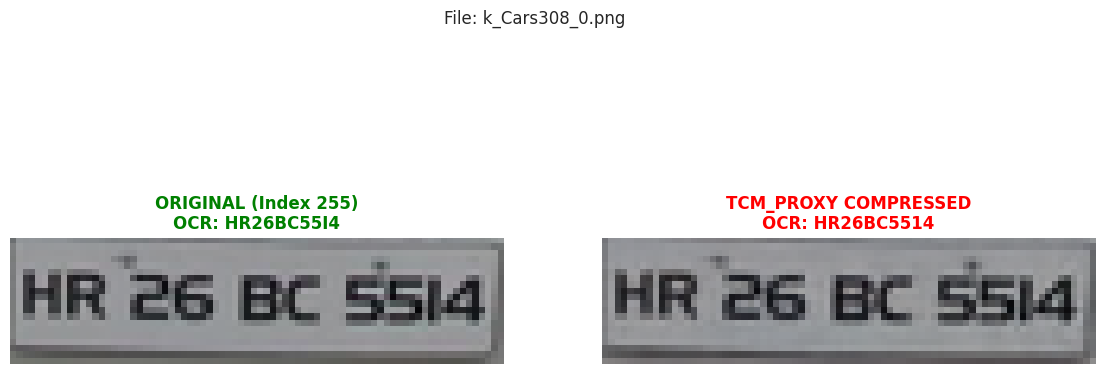

In [11]:
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
IMAGE_INDEX = 255

# --- STEP 1: RESTORE THE FUNCTION ---
def clean_text_func(text):
    """Renamed to avoid any future variable clashing"""
    return re.sub(r'[^A-Z0-9]', '', str(text).upper())

def get_ocr_prediction_fixed(img_np, engine_name):
    pred_text = ""
    try:
        if engine_name == "paddle":
            raw_res = ocr.ocr(img_np, cls=True)
            if raw_res and raw_res[0]:
                pred_text = " ".join([line[1][0] for line in raw_res[0]])
        elif engine_name == "easyocr":
            pred_text = " ".join(easy_reader.readtext(img_np, detail=0))
        elif engine_name == "doctr":
            result = doctr_model([img_np])
            words = [word.value for page in result.pages for block in page.blocks
                     for line in block.lines for word in line.words]
            pred_text = "".join(words)
    except: pass
    return clean_text_func(pred_text)

# --- STEP 2: VISUALIZATION ---
all_files = sorted(os.listdir(unified_dir)) # sorted for consistent indexing

if not all_files:
    print("Dataset folder is empty!")
elif IMAGE_INDEX >= len(all_files):
    print(f"Error: Index {IMAGE_INDEX} is out of range. Max index is {len(all_files) - 1}.")
else:
    sample_img_name = all_files[IMAGE_INDEX]
    img_path = os.path.join(unified_dir, sample_img_name)
    original_img = Image.open(img_path).convert('RGB')

    # OCR Before
    ocr_before = get_ocr_prediction_fixed(np.array(original_img), "paddle")

    # Process through tcm_proxy
    padded_img, (orig_w, orig_h) = pad_to_multiple_of_64(original_img)
    net = comp_models["tcm_proxy"]
    x = T.ToTensor()(padded_img).unsqueeze(0).to(device)

    with torch.no_grad():
        out = net(x)
        reconstructed_img = T.ToPILImage()(out['x_hat'].squeeze(0).cpu().clamp(0, 1))
        reconstructed_img = reconstructed_img.crop((0, 0, orig_w, orig_h))

    # OCR After
    ocr_after = get_ocr_prediction_fixed(np.array(reconstructed_img), "paddle")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(original_img)
    axes[0].set_title(f"ORIGINAL (Index {IMAGE_INDEX})\nOCR: {ocr_before}", color='green', fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(reconstructed_img)
    status_color = 'blue' if ocr_before == ocr_after else 'red'
    axes[1].set_title(f"TCM_PROXY COMPRESSED\nOCR: {ocr_after}", color=status_color, fontweight='bold')
    axes[1].axis('off')

    plt.suptitle(f"File: {sample_img_name}")
    plt.show()